In [1]:
import pickle
import torch
import nltk
import matplotlib.pyplot as plt
from pprint import pprint

In [2]:
import sys
sys.path.append('../')
from xsbert.utils import plot_attributions
from xsbert.deep_comparison import SampleCDF
from msmarco_utils import (
    token_to_word_attributions,
    divide_stop_and_content_words,
    extract_stop_and_content_word_attribution,
    process_samples
)

/mount/arbeitsdaten/tcl/Users/moellels/anaconda/envs/emb/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


In [6]:
path = 'data/sbert_msmarco11_n1000_attr.pkl'
results = pickle.load(open(path, 'rb'))
print(len(results))

1000


In [7]:
stop_attributions, content_attributions = process_samples(results)

In [8]:
print(min(stop_attributions), max(stop_attributions))
print(min(content_attributions), max(content_attributions))

-0.040984116 0.4288593
-0.23607771 1.6049643


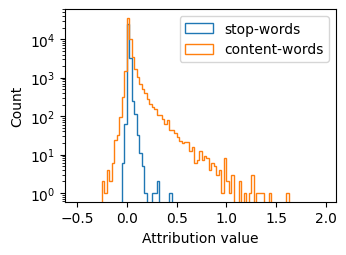

In [12]:
cumulative = False
fig = plt.figure(figsize=(3.5, 2.5))
bins = torch.arange(-.5, 2.0, 0.025)
plt.hist(stop_attributions, histtype='step', bins=bins, cumulative=cumulative, density=cumulative, label='stop-words')
plt.hist(content_attributions, histtype='step', bins=bins, cumulative=cumulative, density=cumulative, label='content-words')
# plt.xticks(torch.arange(0, 1.5, .25))
plt.ylabel('Count')
plt.xlabel('Attribution value')
plt.legend()
if not cumulative:
    plt.yscale('log')
# plt.savefig('../../results/zurich/msmarco/passage_tot_attr.pdf', bbox_inches='tight')
plt.show()